# Honda US Market Analysis 

## Project Overview

This notebook performs a comprehensive Exploratory Data Analysis (EDA) on Honda vehicle sales data across the United States. The dataset contains **~5,000 listings** spanning multiple years, models, conditions (New, Used, Certified), and geographic markets.

### Business Objectives

As a Data Analyst in the automotive industry, the goal of this analysis is to answer key business questions:

1. **Pricing & Depreciation**: How do Honda vehicles depreciate over time? Which models retain their value best?
2. **Consumer Satisfaction**: What do consumers value most? How do ratings correlate with pricing?
3. **Hybrid vs Gasoline**: Is Honda's hybrid strategy resonating with consumers? Where is adoption strongest?
4. **Market Geography**: How do pricing and preferences vary across US states and regions?

### Deliverables

- A cleaned, analysis-ready dataset (`honda_cleaned.csv`)
- Key statistical insights and visualizations

---


## 1. Import Libraries & Load Data

We begin by importing the necessary libraries and loading the raw CSV dataset.


In [1]:
import sys
!{sys.executable} -m pip install plotly
!{sys.executable} -m pip install nbformat --upgrade


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached nbformat-5.10.4-py3-none-any.whl.metadata (3.6 kB)
  Using cached fastjsonschema-2.21.2-py3-none-any.whl.metadata (2.3 kB)
Using cached nbformat-5.10.4-py3-none-any.whl (78 kB)
Using cached fastjsonschema-2.21.2-py3-none-any.whl (24 kB)



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings('ignore')

# Configure display options
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Visualization style
sns.set_theme(style="darkgrid", palette="husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Libraries loaded successfully")


Libraries loaded successfully


In [3]:
# Load the raw dataset
df_raw = pd.read_csv('honda_sell_data.csv')

print(f"Dataset Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"\nColumn Names:\n{df_raw.columns.tolist()}")
df_raw.head(10)


Dataset Shape: 4,999 rows × 25 columns

Column Names:
['Year', 'Make', 'Model', 'Condition', 'Price', 'Consumer_Rating', 'Consumer_Review_#', 'Exterior_Color', 'Interior_Color', 'Drivetrain', 'MPG', 'Fuel_Type', 'Transmission', 'Engine', 'VIN', 'Stock_#', 'Mileage', 'Comfort_Rating', 'Interior_Design_Rating', 'Performance_Rating', 'Value_For_Money_Rating', 'Exterior_Styling_Rating', 'Reliability_Rating', 'State', 'Seller_Type']


,Year,Make,Model,Condition,Price,Consumer_Rating,Consumer_Review_#,Exterior_Color,Interior_Color,Drivetrain,MPG,Fuel_Type,Transmission,Engine,VIN,Stock_#,Mileage,Comfort_Rating,Interior_Design_Rating,Performance_Rating,Value_For_Money_Rating,Exterior_Styling_Rating,Reliability_Rating,State,Seller_Type
0,2023,Honda,Ridgeline RTL,New,"$46,370",4.80,9,Platinum White Pearl,Beige,All-wheel Drive,NaN,Gasoline,Automatic,3.5L V6 24V GDI SOHC,5FPYK3F58PB011817,00830164,10,5.00,4.80,4.80,4.20,5.00,5.00,CA,Dealer
1,2023,Honda,CR-V Hybrid Sport,New,"$34,150",1.70,24,Platinum White Pearl,Black,FWD,NaN,Hybrid,Automatic CVT,2.0L I4 16V GDI DOHC Hybrid,2HKRS5H5XPH702953,6402953,–,5.00,3.00,4.00,4.00,5.00,5.00,CA,Dealer
2,2023,Honda,CR-V Hybrid Sport,New,"$34,245",4.70,2869,Meteorite Gray Metallic,Black,Front-wheel Drive,NaN,Hybrid,Automatic CVT,2.0L I4 16V GDI DOHC Hybrid,2HKRS5H55PH704805,PH704805,1,5.00,3.00,4.00,4.00,5.00,5.00,CA,Dealer
3,2022,Honda,Pilot TrailSport,New,"$46,500",5.00,12,Sonic Gray Pearl,Black,All-wheel Drive,19–25,Gasoline,9-Speed Automatic,3.5L V6 24V GDI SOHC,5FNYF6H82NB100429,5700429B,5,5.00,5.00,5.00,5.00,5.00,5.00,CA,Dealer
4,2023,Honda,CR-V Hybrid Sport Touring,New,"$40,395",4.40,12,Crystal Black Pearl,Black,All-wheel Drive,NaN,Hybrid,Automatic CVT,2.0L I4 16V GDI DOHC Hybrid,2HKRS6H90PH805954,5705954,5,5.00,3.00,4.00,4.00,5.00,5.00,CA,Dealer
5,2023,Honda,Odyssey EX-L,New,"$42,250",4.40,12,Pacific Pewter Metallic,Mocha,Front-wheel Drive,NaN,Gasoline,10-Speed Automatic,3.5L V6 24V GDI SOHC,5FNRL6H67PB024270,5724270,5,5.00,5.00,4.00,4.00,4.00,5.00,CA,Dealer
6,2023,Honda,CR-V Hybrid Sport,New,"$34,090",4.40,12,Urban Gray Pearl,Black,FWD,NaN,Hybrid,Automatic CVT,2.0L I4 16V GDI DOHC Hybrid,2HKRS5H56PH703596,5703596A,–,5.00,3.00,4.00,4.00,5.00,5.00,CA,Dealer
7,2023,Honda,CR-V Hybrid Sport Touring,New,"$39,845",1.20,70,Crystal Black Pearl,Black,All-wheel Drive,NaN,Hybrid,Automatic CVT,2.0L I4 16V GDI DOHC Hybrid,2HKRS6H9XPH805315,2905315X,–,5.00,3.00,4.00,4.00,5.00,5.00,CA,Dealer
8,2023,Honda,CR-V Hybrid Sport Touring,New,"$40,240",1.20,70,Platinum White Pearl,Black,All-wheel Drive,NaN,Hybrid,Automatic CVT,2.0L I4 16V GDI DOHC Hybrid,2HKRS6H97PH800573,2900573X,–,5.00,3.00,4.00,4.00,5.00,5.00,CA,Dealer
9,2023,Honda,CR-V Hybrid Sport,New,"$34,700",1.20,70,Urban Gray Pearl,Black,FWD,NaN,Hybrid,Automatic CVT,2.0L I4 16V GDI DOHC Hybrid,2HKRS5H54PH703791,2903791,–,5.00,3.00,4.00,4.00,5.00,5.00,CA,Dealer


In [4]:
# Quick overview of data types and non-null counts
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Year                     4999 non-null   int64  
 1   Make                     4999 non-null   object 
 2   Model                    4999 non-null   object 
 3   Condition                4999 non-null   object 
 4   Price                    4999 non-null   object 
 5   Consumer_Rating          4999 non-null   float64
 6   Consumer_Review_#        4999 non-null   int64  
 7   Exterior_Color           4988 non-null   object 
 8   Interior_Color           4988 non-null   object 
 9   Drivetrain               4988 non-null   object 
 10  MPG                      3514 non-null   object 
 11  Fuel_Type                4988 non-null   object 
 12  Transmission             4988 non-null   object 
 13  Engine                   4988 non-null   object 
 14  VIN                     

## 2. Data Quality Assessment

Before any analysis, we must thoroughly inspect the data for quality issues. A rigorous data quality assessment demonstrates professional-grade analytical discipline.

### 2.1 Missing Values Analysis


Columns with Missing Values:

                         Missing_Count  Missing_Pct
MPG                               1485        29.71
Reliability_Rating                 552        11.04
Exterior_Styling_Rating            552        11.04
Value_For_Money_Rating             552        11.04
Performance_Rating                 552        11.04
Interior_Design_Rating             552        11.04
Comfort_Rating                     552        11.04
Seller_Type                         73         1.46
State                               73         1.46
Engine                              11         0.22
Mileage                             11         0.22
Stock_#                             11         0.22
VIN                                 11         0.22
Transmission                        11         0.22
Fuel_Type                           11         0.22
Drivetrain                          11         0.22
Interior_Color                      11         0.22
Exterior_Color                    

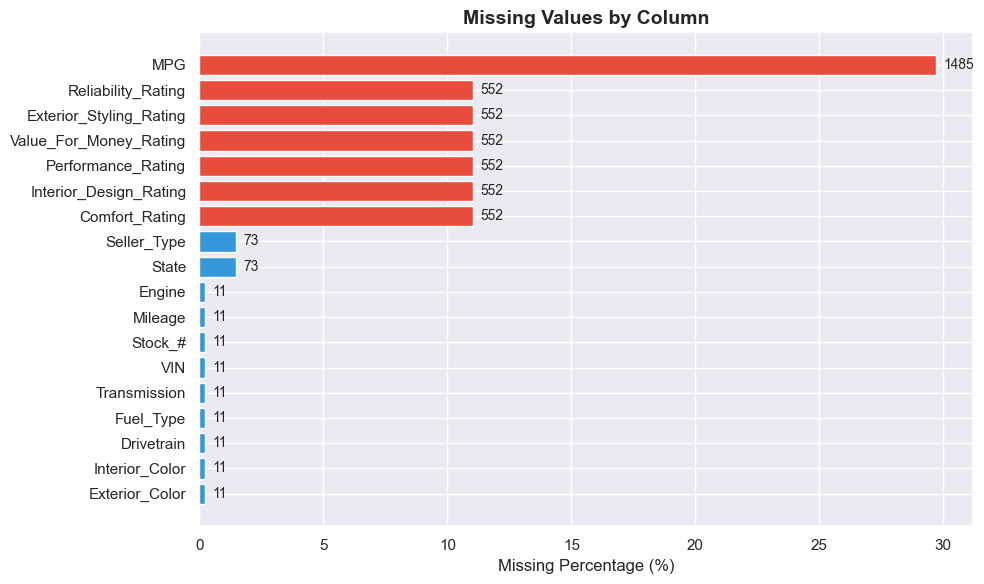

In [5]:
# Calculate missing values
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_Pct': missing_pct
}).sort_values('Missing_Count', ascending=False)

# Only show columns with missing values
missing_df = missing_df[missing_df['Missing_Count'] > 0]
print("Columns with Missing Values:\n")
print(missing_df.to_string())

# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if pct > 10 else '#f39c12' if pct > 5 else '#3498db' 
          for pct in missing_df['Missing_Pct']]
bars = ax.barh(missing_df.index, missing_df['Missing_Pct'], color=colors)
ax.set_xlabel('Missing Percentage (%)')
ax.set_title('Missing Values by Column', fontsize=14, fontweight='bold')
ax.invert_yaxis()

for bar, count in zip(bars, missing_df['Missing_Count']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, 
            f'{int(count)}', va='center', fontsize=10)

plt.tight_layout()
plt.show()


### 2.2 Data Type Validation & Dirty Value Inspection

Several columns contain values that need type conversion or cleaning:
- **Price**: Stored as string with `$` and commas
- **Mileage**: Contains `-` (dash) instead of NaN
- **MPG**: Range format like `"19-25"` instead of numeric
- **Drivetrain**: Duplicate labels (`FWD` = `Front-wheel Drive`, `AWD` = `All-wheel Drive`)
- **Fuel_Type**: Contains misplaced transmission values


In [6]:
# Inspect problematic columns
print("=" * 60)
print("PRICE Sample values:")
print(df_raw['Price'].head(10).tolist())
print(f"  Dtype: {df_raw['Price'].dtype}")

print("\n" + "=" * 60)
print("MILEAGE Unique non-numeric values:")
mileage_non_numeric = df_raw[pd.to_numeric(df_raw['Mileage'], errors='coerce').isna()]['Mileage'].unique()
print(f"  {mileage_non_numeric}")

print("\n" + "=" * 60)
print("MPG Sample values:")
print(df_raw['MPG'].dropna().head(10).tolist())

print("\n" + "=" * 60)
print("DRIVETRAIN All unique values:")
print(df_raw['Drivetrain'].value_counts())

print("\n" + "=" * 60)
print("FUEL_TYPE All unique values:")
print(df_raw['Fuel_Type'].value_counts())

print("\n" + "=" * 60)
print("CONDITION All unique values:")
print(df_raw['Condition'].value_counts())


PRICE Sample values:
['$46,370', '$34,150', '$34,245', '$46,500', '$40,395', '$42,250', '$34,090', '$39,845', '$40,240', '$34,700']
  Dtype: object

MILEAGE Unique non-numeric values:
  ['–' nan 'USB' 'Premium' 'HomeLinkRear' 'Alloy' 'BluetoothUSB' 'Apple']

MPG Sample values:
['19–25', '19–26', '19–25', '19–25', '18–24', '18–24', '19–24', '29–35', '25–30', '27–32']

DRIVETRAIN All unique values:
Drivetrain
Front-wheel Drive    2327
All-wheel Drive      2285
FWD                   170
AWD                   110
Four-wheel Drive       77
Rear-wheel Drive       14
–                       5
Name: count, dtype: int64

FUEL_TYPE All unique values:
Fuel_Type
Gasoline                  4393
Hybrid                     588
A/T                          2
6-Speed M/T                  2
5-Speed A/T                  1
CVT Transmission             1
Compressed Natural Gas       1
Name: count, dtype: int64

CONDITION All unique values:
Condition
New                2697
Used               2022
Honda Cert

In [30]:
# Check for near-empty rows (rows where most columns are NaN)
null_per_row = df_raw.isnull().sum(axis=1)
print("Rows by number of null columns:")
print(null_per_row.value_counts().sort_index())

# Identify rows with excessive nulls (> 10 columns)
empty_rows = df_raw[null_per_row > 10]
print(f"\nFound {len(empty_rows)} rows with >10 null columns candidates for removal")
if len(empty_rows) > 0:
    print(empty_rows[['Year', 'Model', 'Condition', 'Price']].head())


Rows by number of null columns:
0     3385
1     1000
2       57
3        5
6       72
7      469
18      11
Name: count, dtype: int64

Found 11 rows with >10 null columns candidates for removal
      Year            Model Condition    Price
179   2023  Ridgeline RTL-E       New  $46,420
485   2023  Ridgeline RTL-E       New  $46,420
1237  2023    Ridgeline RTL       New  $43,975
1998  2018         Civic Si      Used  $24,998
2242  2019     Odyssey EX-L      Used  $30,995


In [8]:
# Check for duplicate VINs (each car should have a unique VIN)
vin_dupes = df_raw[df_raw['VIN'].notna()]['VIN'].duplicated().sum()
print(f"Duplicate VINs found: {vin_dupes}")

# Check for fully duplicate rows
full_dupes = df_raw.duplicated().sum()
print(f"Fully duplicate rows: {full_dupes}")


Duplicate VINs found: 0
Fully duplicate rows: 0


## 3. Data Cleaning

Based on the data quality assessment, we now systematically clean each problematic column. The goal is to produce a **structured, type-correct, analysis-ready dataset**.

### Cleaning Strategy:
1. Remove near-empty rows (>10 null columns)
2. Clean `Price` numeric
3. Clean `Mileage` numeric
4. Parse `MPG` range `MPG_City`, `MPG_Highway`, `MPG_Combined`
5. Standardize `Drivetrain` labels
6. Fix `Fuel_Type` misplaced values
7. Extract engine specifications


In [9]:
# Create a working copy
df = df_raw.copy()
print(f"Starting shape: {df.shape}")

# Step 1: Remove near-empty rows
null_per_row = df.isnull().sum(axis=1)
df = df[null_per_row <= 10].reset_index(drop=True)
print(f"After removing near-empty rows: {df.shape}")


Starting shape: (4999, 25)
After removing near-empty rows: (4988, 25)


### 3.1 Clean Price Column

Convert from string format (`$46,370`) to numeric float.


In [10]:
# Clean Price: remove $ and commas, convert to float
df['Price'] = (df['Price']
               .str.replace('$', '', regex=False)
               .str.replace(',', '', regex=False))

# Handle non-numeric values like 'Not Priced'
non_numeric_prices = df[pd.to_numeric(df['Price'], errors='coerce').isna()]['Price'].unique()
print(f"Non-numeric price values found: {non_numeric_prices}")

df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Drop rows without a valid price
before_count = len(df)
df = df[df['Price'].notna()].reset_index(drop=True)
print(f"Dropped {before_count - len(df)} rows with invalid prices")

print(f"\nPrice dtype: {df['Price'].dtype}")
print(f"Price range: ${df['Price'].min():,.0f} - ${df['Price'].max():,.0f}")
print(f"Price mean:  ${df['Price'].mean():,.0f}")
print(f"Price median: ${df['Price'].median():,.0f}")
print(f"\nPrice distribution (percentiles):")
print(df['Price'].describe().to_string())


Non-numeric price values found: ['Not Priced']
Dropped 39 rows with invalid prices

Price dtype: float64
Price range: $1,995 - $69,980
Price mean:  $33,712
Price median: $33,949

Price distribution (percentiles):
count    4949.00
mean    33711.93
std     10325.43
min      1995.00
25%     26998.00
50%     33949.00
75%     41799.00
max     69980.00


### 3.2 Clean Mileage Column

Replace dash characters (`–`) with NaN, then convert to numeric.


In [11]:
# Clean Mileage: replace dashes/special chars with NaN, convert to numeric
df['Mileage'] = df['Mileage'].replace('–', np.nan)
df['Mileage'] = df['Mileage'].replace('—', np.nan)
df['Mileage'] = pd.to_numeric(df['Mileage'], errors='coerce')

print(f"Mileage dtype: {df['Mileage'].dtype}")
print(f"Mileage null count: {df['Mileage'].isna().sum()}")
print(f"Mileage range: {df['Mileage'].min():,.0f} — {df['Mileage'].max():,.0f}")
print(f"\nMileage distribution:")
print(df['Mileage'].describe().to_string())


Mileage dtype: float64
Mileage null count: 287
Mileage range: 0 — 259,029

Mileage distribution:
count     4662.00
mean     24812.29
std      37684.58
min          0.00
25%          5.00
50%        704.50
75%      39290.50
max     259029.00


### 3.3 Parse MPG Range

The MPG column contains range strings like `"19–25"`. We'll split these into city and highway values, then compute a combined MPG estimate.


In [12]:
def parse_mpg(mpg_str):
    """Parse MPG range string (e.g., '19–25') into city and highway values."""
    if pd.isna(mpg_str):
        return pd.Series([np.nan, np.nan])
    
    mpg_str = str(mpg_str)
    # Try different dash separators
    for sep in ['–', '—', '-']:
        if sep in mpg_str:
            parts = mpg_str.split(sep)
            try:
                city = float(parts[0].strip())
                highway = float(parts[1].strip())
                return pd.Series([city, highway])
            except (ValueError, IndexError):
                return pd.Series([np.nan, np.nan])
    
    # Single value
    try:
        val = float(mpg_str.strip())
        return pd.Series([val, val])
    except ValueError:
        return pd.Series([np.nan, np.nan])

# Apply parsing
df[['MPG_City', 'MPG_Highway']] = df['MPG'].apply(parse_mpg)
df['MPG_Combined'] = ((df['MPG_City'] + df['MPG_Highway']) / 2).round(1)

print(f"MPG_City null count:    {df['MPG_City'].isna().sum()}")
print(f"MPG_Highway null count: {df['MPG_Highway'].isna().sum()}")
print(f"\nMPG_Combined sample:")
print(df[['Model', 'MPG', 'MPG_City', 'MPG_Highway', 'MPG_Combined']].dropna(subset=['MPG_Combined']).head(10))


MPG_City null count:    1451
MPG_Highway null count: 1451

MPG_Combined sample:
                    Model    MPG  MPG_City  MPG_Highway  MPG_Combined
3        Pilot TrailSport  19–25     19.00        25.00         22.00
12  Pilot Special Edition  19–26     19.00        26.00         22.50
14            Pilot Sport  19–25     19.00        25.00         22.00
15            Pilot Elite  19–25     19.00        25.00         22.00
18        Ridgeline RTL-E  18–24     18.00        24.00         21.00
19        Ridgeline RTL-E  18–24     18.00        24.00         21.00
20         Passport Elite  19–24     19.00        24.00         21.50
22      Accord Sport 1.5T  29–35     29.00        35.00         32.00
23             HR-V Sport  25–30     25.00        30.00         27.50
24              CR-V EX-L  27–32     27.00        32.00         29.50


### 3.4 Standardize Drivetrain Labels

Unify duplicate labels: `FWD` → `Front-wheel Drive`, `AWD` → `All-wheel Drive`.


In [13]:
# Standardize Drivetrain
drivetrain_map = {
    'FWD': 'Front-wheel Drive',
    'AWD': 'All-wheel Drive',
    '–': np.nan
}
df['Drivetrain'] = df['Drivetrain'].replace(drivetrain_map)

# Also clean any dash characters
df.loc[df['Drivetrain'].str.contains('–|—', na=False), 'Drivetrain'] = np.nan

print("Drivetrain values after cleaning:")
print(df['Drivetrain'].value_counts(dropna=False))


Drivetrain values after cleaning:
Drivetrain
Front-wheel Drive    2482
All-wheel Drive      2371
Four-wheel Drive       77
Rear-wheel Drive       14
NaN                     5
Name: count, dtype: int64


### 3.5 Fix Fuel Type Column

Some rows have transmission values (`A/T`, `6-Speed M/T`, `CVT Transmission`) in the Fuel_Type column. We'll fix these based on the vehicle model.


In [14]:
# Fix Fuel_Type — replace misplaced transmission values
invalid_fuel = ['A/T', '6-Speed M/T', '5-Speed A/T', 'CVT Transmission']
mask = df['Fuel_Type'].isin(invalid_fuel)
print(f"Rows with invalid Fuel_Type: {mask.sum()}")

# For these rows, assign Gasoline (the most common fuel type, and none of these are hybrids)
df.loc[mask, 'Fuel_Type'] = 'Gasoline'

# Also handle the rare Compressed Natural Gas — keep it
print("\nFuel_Type values after cleaning:")
print(df['Fuel_Type'].value_counts(dropna=False))


Rows with invalid Fuel_Type: 6

Fuel_Type values after cleaning:
Fuel_Type
Gasoline                  4361
Hybrid                     587
Compressed Natural Gas       1
Name: count, dtype: int64


### 3.6 Extract Engine Specifications

Parse the `Engine` column to extract displacement (liters) and cylinder count as separate numeric features.


In [15]:
import re

def extract_displacement(engine_str):
    """Extract engine displacement in liters from engine description."""
    if pd.isna(engine_str):
        return np.nan
    match = re.search(r'(\d+\.\d+)\s*L', str(engine_str))
    return float(match.group(1)) if match else np.nan

def extract_cylinders(engine_str):
    """Extract cylinder count from engine description."""
    if pd.isna(engine_str):
        return np.nan
    engine_str = str(engine_str)
    # Match patterns like 'V6', 'I4', 'I-4', 'V-6'
    match = re.search(r'[VI]-?(\d)', engine_str)
    if match:
        return int(match.group(1))
    # Match '4 Cylinder' or '6 Cylinder'
    match = re.search(r'(\d)\s*[Cc]ylinder', engine_str)
    if match:
        return int(match.group(1))
    return np.nan

df['Engine_Displacement_L'] = df['Engine'].apply(extract_displacement)
df['Engine_Cylinders'] = df['Engine'].apply(extract_cylinders)

print("Engine_Displacement_L distribution:")
print(df['Engine_Displacement_L'].value_counts().sort_index())
print(f"\nEngine_Cylinders distribution:")
print(df['Engine_Cylinders'].value_counts().sort_index())


Engine_Displacement_L distribution:
Engine_Displacement_L
1.30       6
1.50    1153
1.60       1
1.70       2
1.80     151
2.00     881
2.20      11
2.30       2
2.40     187
3.00       1
3.50    2290
Name: count, dtype: int64

Engine_Cylinders distribution:
Engine_Cylinders
4.00    2540
6.00    2399
Name: count, dtype: int64


## 4. Feature Engineering

Create new derived features that will unlock deeper analytical insights and serve as the backbone for our Streamlit dashboard.


In [16]:
# 4.1 Model Family — Extract base model name
# e.g., "CR-V EX-L" → "CR-V", "Accord Sport 1.5T" → "Accord"
def extract_model_family(model_str):
    """Extract the base model family from the full model name."""
    model_str = str(model_str)
    families = [
        'Ridgeline', 'Pilot', 'Passport', 'CR-V', 'HR-V', 
        'Odyssey', 'Accord', 'Civic', 'Fit', 'Insight',
        'CR-Z', 'Crosstour', 'Element', 'S2000'
    ]
    for family in families:
        if family.lower() in model_str.lower():
            return family
    return 'Other'

df['Model_Family'] = df['Model'].apply(extract_model_family)

# 4.2 Vehicle Age
df['Vehicle_Age'] = 2023 - df['Year']

# 4.3 Is_Hybrid flag
df['Is_Hybrid'] = df['Fuel_Type'] == 'Hybrid'

# 4.4 US Region mapping
state_to_region = {
    'CT': 'Northeast', 'ME': 'Northeast', 'MA': 'Northeast', 'NH': 'Northeast',
    'RI': 'Northeast', 'VT': 'Northeast', 'NJ': 'Northeast', 'NY': 'Northeast',
    'PA': 'Northeast', 'DE': 'Northeast', 'MD': 'Northeast', 'DC': 'Northeast',
    'IL': 'Midwest', 'IN': 'Midwest', 'MI': 'Midwest', 'OH': 'Midwest',
    'WI': 'Midwest', 'IA': 'Midwest', 'KS': 'Midwest', 'MN': 'Midwest',
    'MO': 'Midwest', 'NE': 'Midwest', 'ND': 'Midwest', 'SD': 'Midwest',
    'AL': 'South', 'AR': 'South', 'FL': 'South', 'GA': 'South',
    'KY': 'South', 'LA': 'South', 'MS': 'South', 'NC': 'South',
    'SC': 'South', 'TN': 'South', 'VA': 'South', 'WV': 'South',
    'OK': 'South', 'TX': 'South',
    'AZ': 'West', 'CO': 'West', 'ID': 'West', 'MT': 'West',
    'NV': 'West', 'NM': 'West', 'UT': 'West', 'WY': 'West',
    'AK': 'West', 'CA': 'West', 'HI': 'West', 'OR': 'West',
    'WA': 'West',
}
df['Region'] = df['State'].map(state_to_region)

# 4.5 Price Per Mile (only meaningful for used/certified cars with mileage > 0)
mask_used = (df['Condition'].isin(['Used', 'Honda Certified'])) & (df['Mileage'] > 0)
df['Price_Per_Mile'] = np.where(mask_used, df['Price'] / df['Mileage'], np.nan)

# 4.6 Has_Ratings flag
df['Has_Ratings'] = df['Comfort_Rating'].notna()

print("Feature Engineering Complete!\n")
print("New columns created:")
new_cols = ['Model_Family', 'Vehicle_Age', 'Is_Hybrid', 'Region', 
            'Price_Per_Mile', 'Has_Ratings', 'MPG_City', 'MPG_Highway', 
            'MPG_Combined', 'Engine_Displacement_L', 'Engine_Cylinders']
for col in new_cols:
    print(f"  • {col}: {df[col].dtype}: {df[col].notna().sum()} non-null values")


Feature Engineering Complete!

New columns created:
  • Model_Family: object: 4949 non-null values
  • Vehicle_Age: int64: 4949 non-null values
  • Is_Hybrid: bool: 4949 non-null values
  • Region: object: 4884 non-null values
  • Price_Per_Mile: float64: 2292 non-null values
  • Has_Ratings: bool: 4949 non-null values
  • MPG_City: float64: 3498 non-null values
  • MPG_Highway: float64: 3498 non-null values
  • MPG_Combined: float64: 3498 non-null values
  • Engine_Displacement_L: float64: 4685 non-null values
  • Engine_Cylinders: float64: 4939 non-null values


In [17]:
# Overview of Model Family distribution
print("Model Family Distribution:")
print(df['Model_Family'].value_counts().to_string())
print(f"\nRegion Distribution:")
print(df['Region'].value_counts().to_string())
print(f"\nVehicle Age Distribution:")
print(df['Vehicle_Age'].value_counts().sort_index().to_string())


Model Family Distribution:
Model_Family
Pilot        1095
CR-V          815
Accord        702
Civic         615
Odyssey       470
Passport      425
Ridgeline     379
HR-V          228
Insight        85
Other          41
Fit            30
Element        19
CR-Z           16
Crosstour      15
S2000          14

Region Distribution:
Region
South        1684
Midwest      1533
Northeast     870
West          797

Vehicle Age Distribution:
Vehicle_Age
0     1557
1     1447
2      336
3      351
4      400
5      206
6      137
7      119
8       79
9       50
10      39
11      35
12      29
13      29
14      28
15      27
16      19
17      16
18      11
19       5
20       4
21       4
22       6
23       3
24       1
25       2
26       3
30       1
31       1
32       1
34       1
36       1
42       1


In [18]:
# Final cleaned dataset overview
print(f"Cleaned Dataset Shape: {df.shape}")
print(f"\nColumn dtypes summary:")
print(df.dtypes.value_counts())
print(f"\nRemaining null values:")
remaining_nulls = df.isnull().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0]
print(remaining_nulls.to_string())
df.head()


Cleaned Dataset Shape: (4949, 36)

Column dtypes summary:
object     16
float64    15
int64       3
bool        2
Name: count, dtype: int64

Remaining null values:
Drivetrain                    5
MPG                        1451
Mileage                     287
Comfort_Rating              529
Interior_Design_Rating      529
Performance_Rating          529
Value_For_Money_Rating      529
Exterior_Styling_Rating     529
Reliability_Rating          529
State                        62
Seller_Type                  62
MPG_City                   1451
MPG_Highway                1451
MPG_Combined               1451
Engine_Displacement_L       264
Engine_Cylinders             10
Region                       65
Price_Per_Mile             2657


,Year,Make,Model,Condition,Price,Consumer_Rating,Consumer_Review_#,Exterior_Color,Interior_Color,Drivetrain,MPG,Fuel_Type,Transmission,Engine,VIN,...,Exterior_Styling_Rating,Reliability_Rating,State,Seller_Type,MPG_City,MPG_Highway,MPG_Combined,Engine_Displacement_L,Engine_Cylinders,Model_Family,Vehicle_Age,Is_Hybrid,Region,Price_Per_Mile,Has_Ratings
0,2023,Honda,Ridgeline RTL,New,46370.00,4.80,9,Platinum White Pearl,Beige,All-wheel Drive,NaN,Gasoline,Automatic,3.5L V6 24V GDI SOHC,5FPYK3F58PB011817,...,5.00,5.00,CA,Dealer,NaN,NaN,NaN,3.50,6.00,Ridgeline,0,False,West,NaN,True
1,2023,Honda,CR-V Hybrid Sport,New,34150.00,1.70,24,Platinum White Pearl,Black,Front-wheel Drive,NaN,Hybrid,Automatic CVT,2.0L I4 16V GDI DOHC Hybrid,2HKRS5H5XPH702953,...,5.00,5.00,CA,Dealer,NaN,NaN,NaN,2.00,4.00,CR-V,0,True,West,NaN,True
2,2023,Honda,CR-V Hybrid Sport,New,34245.00,4.70,2869,Meteorite Gray Metallic,Black,Front-wheel Drive,NaN,Hybrid,Automatic CVT,2.0L I4 16V GDI DOHC Hybrid,2HKRS5H55PH704805,...,5.00,5.00,CA,Dealer,NaN,NaN,NaN,2.00,4.00,CR-V,0,True,West,NaN,True
3,2022,Honda,Pilot TrailSport,New,46500.00,5.00,12,Sonic Gray Pearl,Black,All-wheel Drive,19–25,Gasoline,9-Speed Automatic,3.5L V6 24V GDI SOHC,5FNYF6H82NB100429,...,5.00,5.00,CA,Dealer,19.00,25.00,22.00,3.50,6.00,Pilot,1,False,West,NaN,True
4,2023,Honda,CR-V Hybrid Sport Touring,New,40395.00,4.40,12,Crystal Black Pearl,Black,All-wheel Drive,NaN,Hybrid,Automatic CVT,2.0L I4 16V GDI DOHC Hybrid,2HKRS6H90PH805954,...,5.00,5.00,CA,Dealer,NaN,NaN,NaN,2.00,4.00,CR-V,0,True,West,NaN,True


## 5. Exploratory Data Analysis

Now that our data is clean and enriched with new features, we dive into the core analysis. Each visualization is designed to answer a specific business question.

### 5.1 Price Distribution Analysis


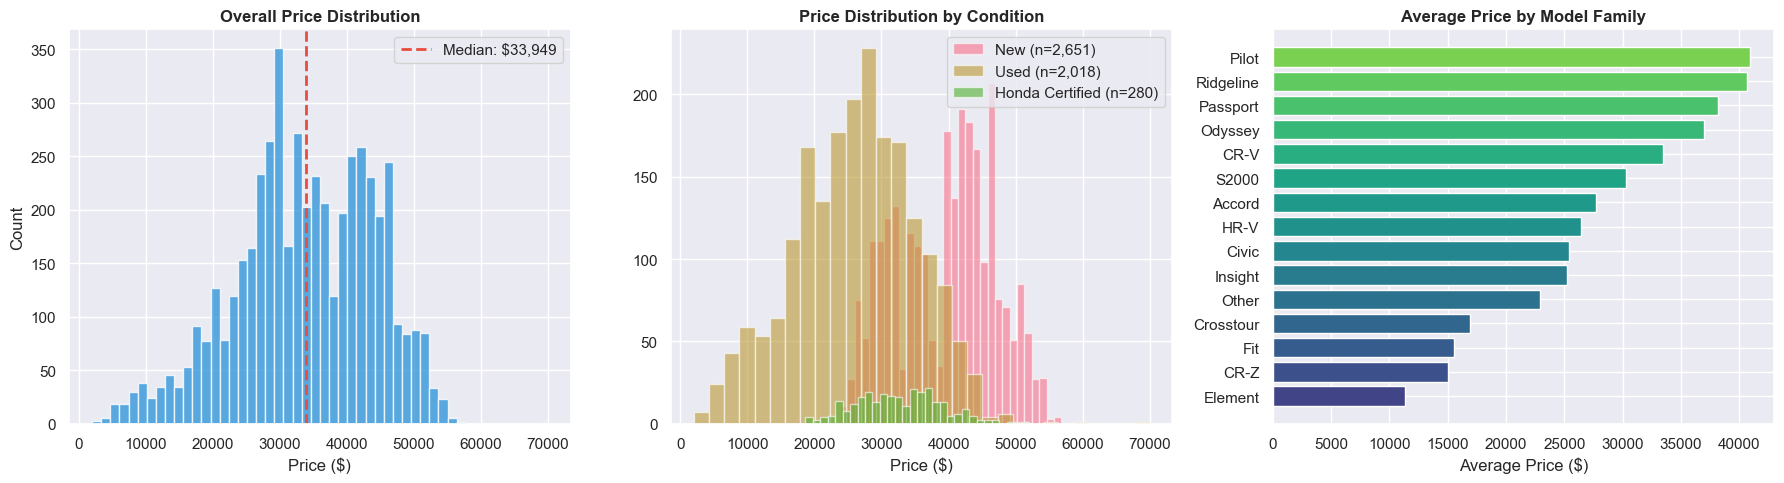

In [19]:
# Price distribution by Condition
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Overall price distribution
axes[0].hist(df['Price'], bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].axvline(df['Price'].median(), color='#e74c3c', linestyle='--', linewidth=2, label=f'Median: ${df["Price"].median():,.0f}')
axes[0].set_title('Overall Price Distribution', fontweight='bold')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Price by Condition
for i, condition in enumerate(['New', 'Used', 'Honda Certified']):
    subset = df[df['Condition'] == condition]['Price']
    axes[1].hist(subset, bins=30, alpha=0.6, label=f'{condition} (n={len(subset):,})')
axes[1].set_title('Price Distribution by Condition', fontweight='bold')
axes[1].set_xlabel('Price ($)')
axes[1].legend()

# Average price by Model Family
model_avg = df.groupby('Model_Family')['Price'].mean().sort_values(ascending=True)
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(model_avg)))
axes[2].barh(model_avg.index, model_avg.values, color=colors)
axes[2].set_title('Average Price by Model Family', fontweight='bold')
axes[2].set_xlabel('Average Price ($)')

plt.tight_layout()
plt.show()


### 5.2 Depreciation Analysis

One of the most valuable insights for both consumers and dealers — how quickly do Honda vehicles lose value?


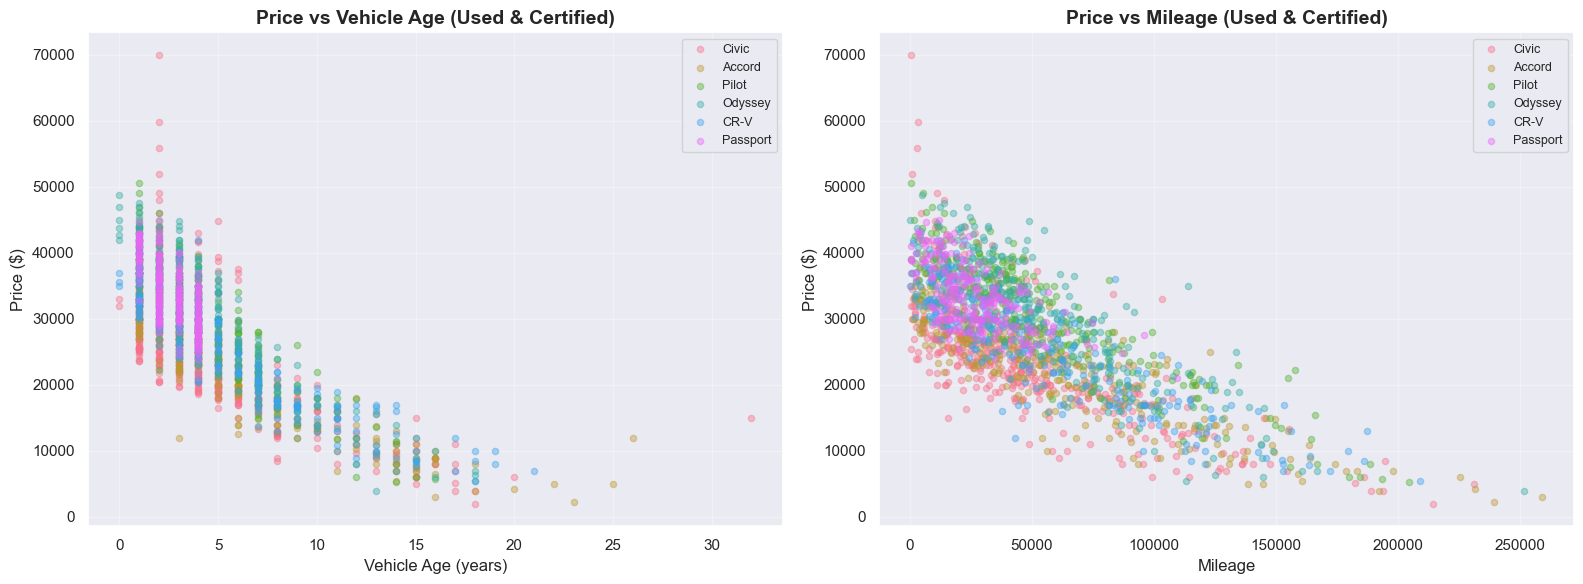


Average Price by Vehicle Age (Top Models):
Model_Family   Accord     CR-V     CR-Z    Civic  Crosstour  Element      Fit     HR-V  Insight  Odyssey    Other  Passport    Pilot  Ridgeline  S2000
Vehicle_Age                                                                                                                                           
0                 NaN 35852.33      NaN 32498.50        NaN      NaN      NaN 29712.50      NaN 44858.50      NaN       NaN      NaN   44951.80    NaN
1            32094.60 35149.53      NaN 28935.65        NaN      NaN      NaN 26399.65 30196.52 41237.40      NaN  40106.25 39504.90   41078.06    NaN
2            30240.56 32096.35      NaN 32711.42        NaN      NaN      NaN 25318.75 28738.85 37933.50 26606.83  34725.38 36258.41   36356.88    NaN
3            26512.25 29757.58      NaN 24858.88        NaN      NaN 18951.60 23469.45 23983.54 36835.45      NaN  33080.04 33220.02   32768.18    NaN
4            25628.59 27592.41      NaN 25464.15  

In [20]:
# Depreciation: Price vs Vehicle Age (used cars only)
df_used = df[df['Condition'].isin(['Used', 'Honda Certified'])].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: Price vs Vehicle Age
top_models = df_used['Model_Family'].value_counts().head(6).index
df_top = df_used[df_used['Model_Family'].isin(top_models)]

for model in top_models:
    subset = df_top[df_top['Model_Family'] == model]
    axes[0].scatter(subset['Vehicle_Age'], subset['Price'], alpha=0.4, s=20, label=model)

axes[0].set_xlabel('Vehicle Age (years)', fontsize=12)
axes[0].set_ylabel('Price ($)', fontsize=12)
axes[0].set_title('Price vs Vehicle Age (Used & Certified)', fontweight='bold', fontsize=14)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Scatter: Price vs Mileage
df_mileage = df_used[df_used['Mileage'].notna() & (df_used['Mileage'] > 0)]
for model in top_models:
    subset = df_mileage[df_mileage['Model_Family'] == model]
    axes[1].scatter(subset['Mileage'], subset['Price'], alpha=0.4, s=20, label=model)

axes[1].set_xlabel('Mileage', fontsize=12)
axes[1].set_ylabel('Price ($)', fontsize=12)
axes[1].set_title('Price vs Mileage (Used & Certified)', fontweight='bold', fontsize=14)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate average depreciation per year by model
depreciation = (df_used.groupby(['Model_Family', 'Vehicle_Age'])['Price']
                .mean().reset_index())
print("\nAverage Price by Vehicle Age (Top Models):")
pivot = depreciation.pivot_table(index='Vehicle_Age', columns='Model_Family', 
                                  values='Price', aggfunc='mean')
print(pivot.head(10).to_string())


### 5.3 Consumer Rating Analysis

Analyze the 6-dimensional rating system to understand what drives consumer satisfaction.


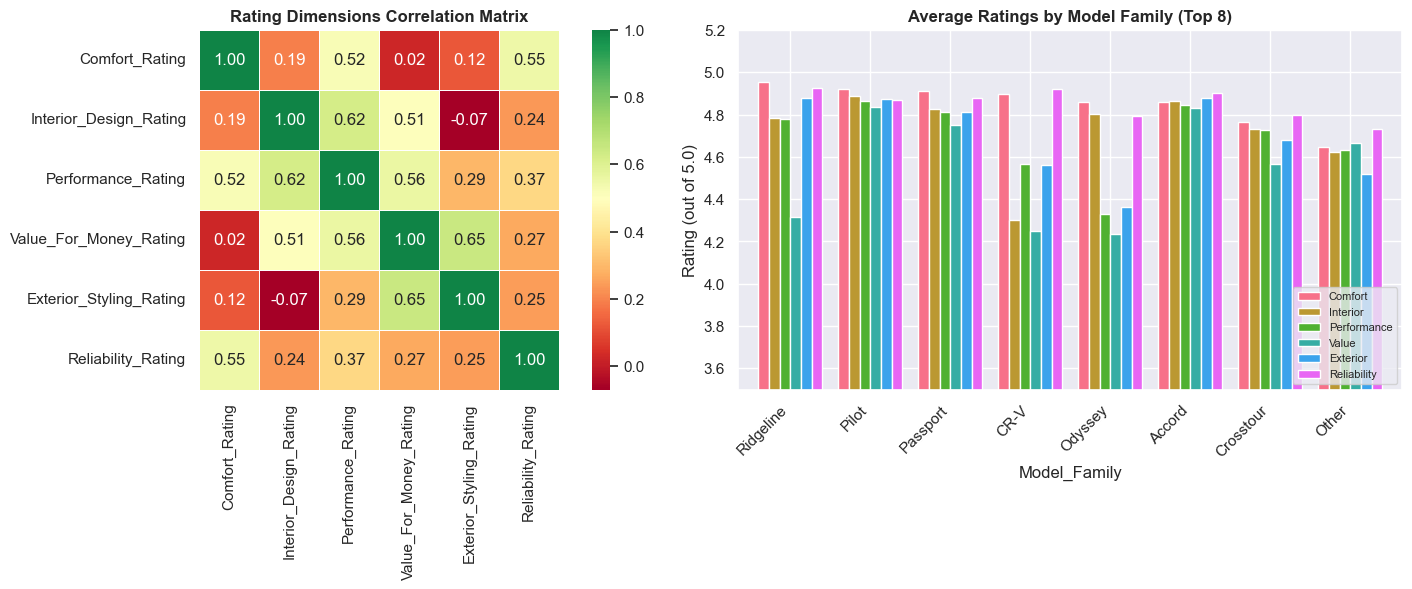

In [21]:
# Filter to rows that have ratings
df_rated = df[df['Has_Ratings']].copy()
rating_cols = ['Comfort_Rating', 'Interior_Design_Rating', 'Performance_Rating', 
               'Value_For_Money_Rating', 'Exterior_Styling_Rating', 'Reliability_Rating']

# Correlation heatmap of ratings
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

corr_matrix = df_rated[rating_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0.5, 
            fmt='.2f', ax=axes[0], square=True, linewidths=0.5)
axes[0].set_title('Rating Dimensions Correlation Matrix', fontweight='bold', fontsize=12)

# Average ratings by Model Family
model_ratings = (df_rated.groupby('Model_Family')[rating_cols]
                 .mean().sort_values('Comfort_Rating', ascending=False))

short_names = ['Comfort', 'Interior', 'Performance', 'Value', 'Exterior', 'Reliability']
model_ratings.columns = short_names

model_ratings.head(8).plot(kind='bar', ax=axes[1], width=0.8)
axes[1].set_title('Average Ratings by Model Family (Top 8)', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Rating (out of 5.0)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].legend(fontsize=8, loc='lower right')
axes[1].set_ylim(3.5, 5.2)

plt.tight_layout()
plt.show()


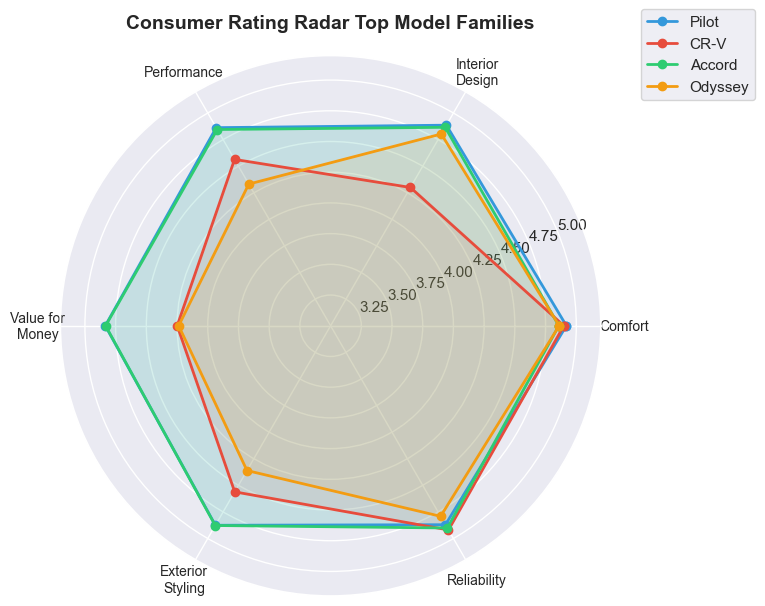

In [22]:
# Radar chart — Compare top 3 Model Families
from matplotlib.patches import FancyBboxPatch

top3_models = df_rated['Model_Family'].value_counts().head(4).index.tolist()
categories = ['Comfort', 'Interior\nDesign', 'Performance', 'Value for\nMoney', 
              'Exterior\nStyling', 'Reliability']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for i, model in enumerate(top3_models):
    subset = df_rated[df_rated['Model_Family'] == model]
    values = subset[rating_cols].mean().values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=model, color=colors[i])
    ax.fill(angles, values, alpha=0.1, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(3.0, 5.2)
ax.set_title('Consumer Rating Radar Top Model Families', fontweight='bold', fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()


### 5.4 Hybrid vs Gasoline Comparison

A critical analysis for understanding Honda's electrification strategy and consumer reception.


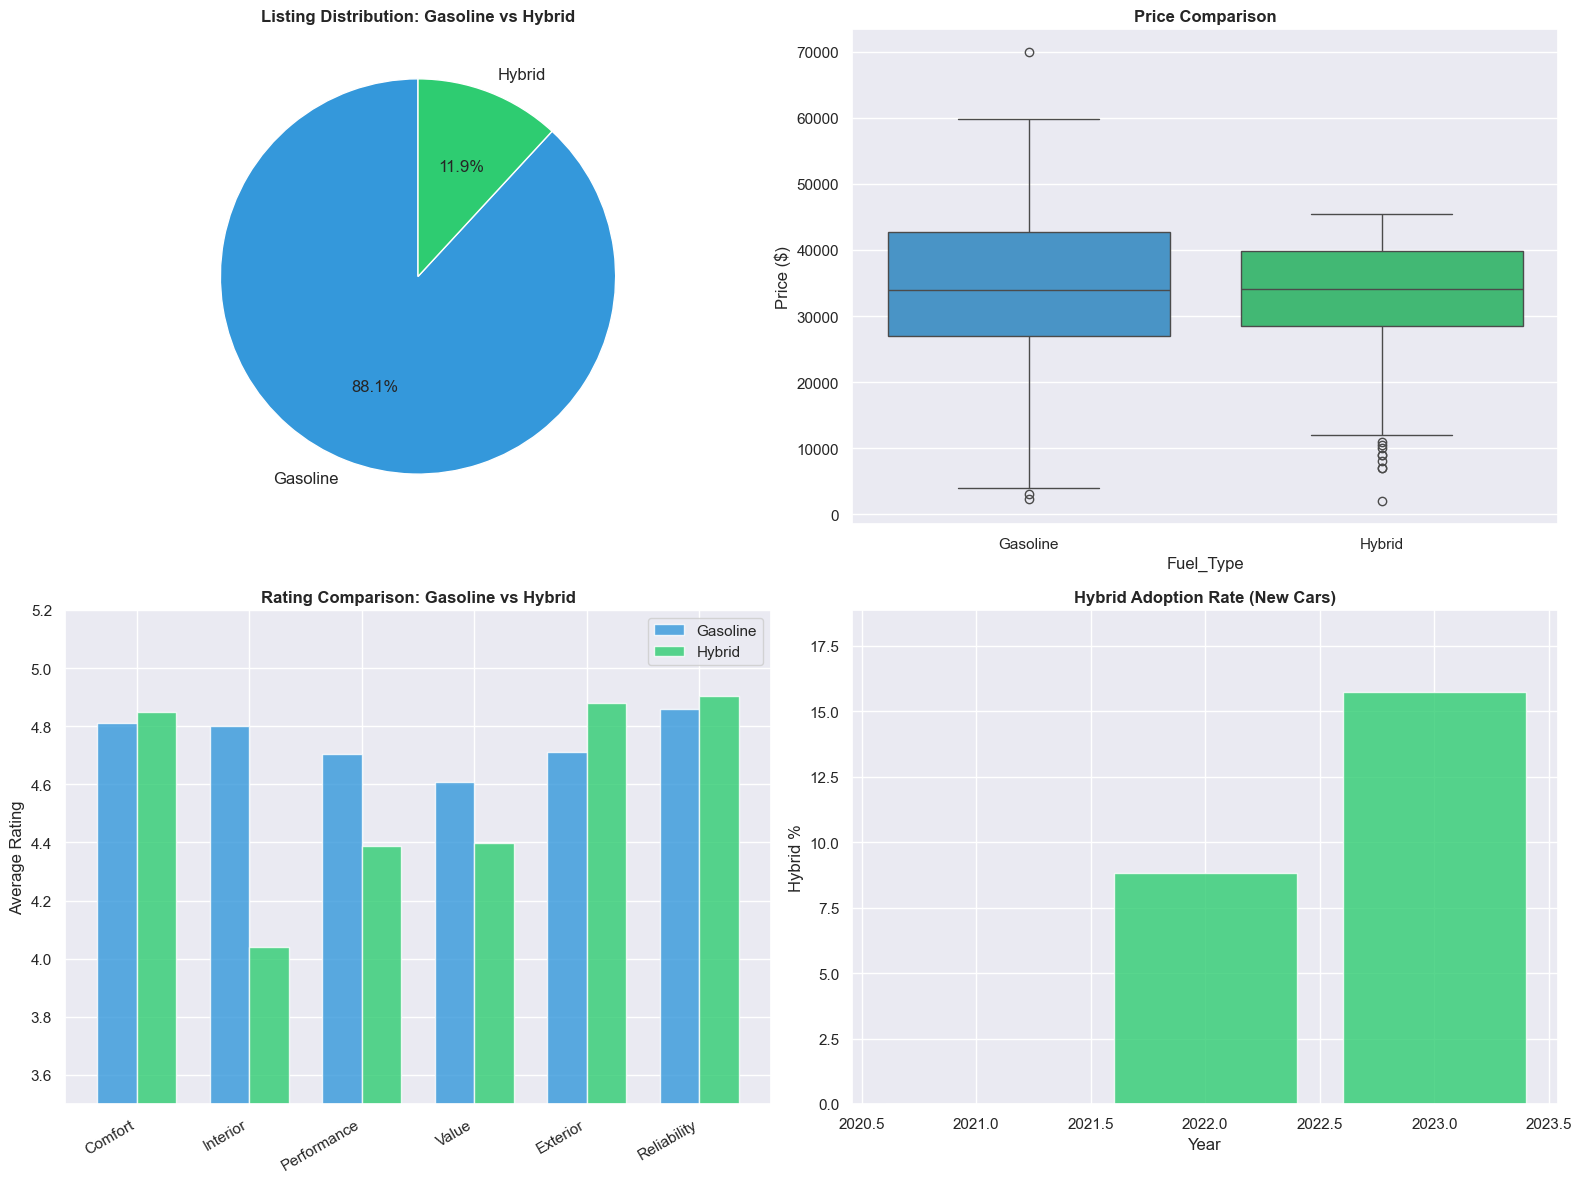


 Summary Statistics: Gasoline vs Hybrid:
           Count  Avg_Price  Median_Price  Avg_Rating
Fuel_Type                                            
Gasoline    4361   33821.49      33900.00        4.58
Hybrid       587   32941.78      34090.00        4.51


In [23]:
# Hybrid vs Gasoline comparison
df_fuel = df[df['Fuel_Type'].isin(['Gasoline', 'Hybrid'])].copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Count comparison
fuel_counts = df_fuel['Fuel_Type'].value_counts()
axes[0, 0].pie(fuel_counts.values, labels=fuel_counts.index, autopct='%1.1f%%',
               colors=['#3498db', '#2ecc71'], startangle=90, textprops={'fontsize': 12})
axes[0, 0].set_title('Listing Distribution: Gasoline vs Hybrid', fontweight='bold')

# 2. Price comparison (box plot)
sns.boxplot(data=df_fuel, x='Fuel_Type', y='Price', ax=axes[0, 1],
            palette={'Gasoline': '#3498db', 'Hybrid': '#2ecc71'})
axes[0, 1].set_title('Price Comparison', fontweight='bold')
axes[0, 1].set_ylabel('Price ($)')

# 3. Average ratings comparison
df_fuel_rated = df_fuel[df_fuel['Has_Ratings']]
fuel_ratings = df_fuel_rated.groupby('Fuel_Type')[rating_cols].mean()
fuel_ratings.columns = short_names

x = np.arange(len(short_names))
width = 0.35
bars1 = axes[1, 0].bar(x - width/2, fuel_ratings.loc['Gasoline'], width, 
                         label='Gasoline', color='#3498db', alpha=0.8)
bars2 = axes[1, 0].bar(x + width/2, fuel_ratings.loc['Hybrid'], width, 
                         label='Hybrid', color='#2ecc71', alpha=0.8)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(short_names, rotation=30, ha='right')
axes[1, 0].set_ylabel('Average Rating')
axes[1, 0].set_title('Rating Comparison: Gasoline vs Hybrid', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].set_ylim(3.5, 5.2)

# 4. Hybrid adoption by year (new cars only)
df_new = df_fuel[df_fuel['Condition'] == 'New']
hybrid_by_year = (df_new.groupby(['Year', 'Fuel_Type']).size()
                  .unstack(fill_value=0))
if 'Hybrid' in hybrid_by_year.columns:
    hybrid_pct = (hybrid_by_year['Hybrid'] / hybrid_by_year.sum(axis=1) * 100)
    hybrid_pct = hybrid_pct[hybrid_pct.index >= 2018]
    axes[1, 1].bar(hybrid_pct.index, hybrid_pct.values, color='#2ecc71', alpha=0.8)
    axes[1, 1].set_xlabel('Year')
    axes[1, 1].set_ylabel('Hybrid %')
    axes[1, 1].set_title('Hybrid Adoption Rate (New Cars)', fontweight='bold')
    axes[1, 1].set_ylim(0, max(hybrid_pct.values) * 1.2)

plt.tight_layout()
plt.show()

# Summary stats
print("\n Summary Statistics: Gasoline vs Hybrid:")
summary = df_fuel.groupby('Fuel_Type').agg(
    Count=('Price', 'count'),
    Avg_Price=('Price', 'mean'),
    Median_Price=('Price', 'median'),
    Avg_Rating=('Consumer_Rating', 'mean')
).round(2)
print(summary.to_string())


### 5.5 Geographic Market Analysis

Understand how Honda's market varies across US states and regions.


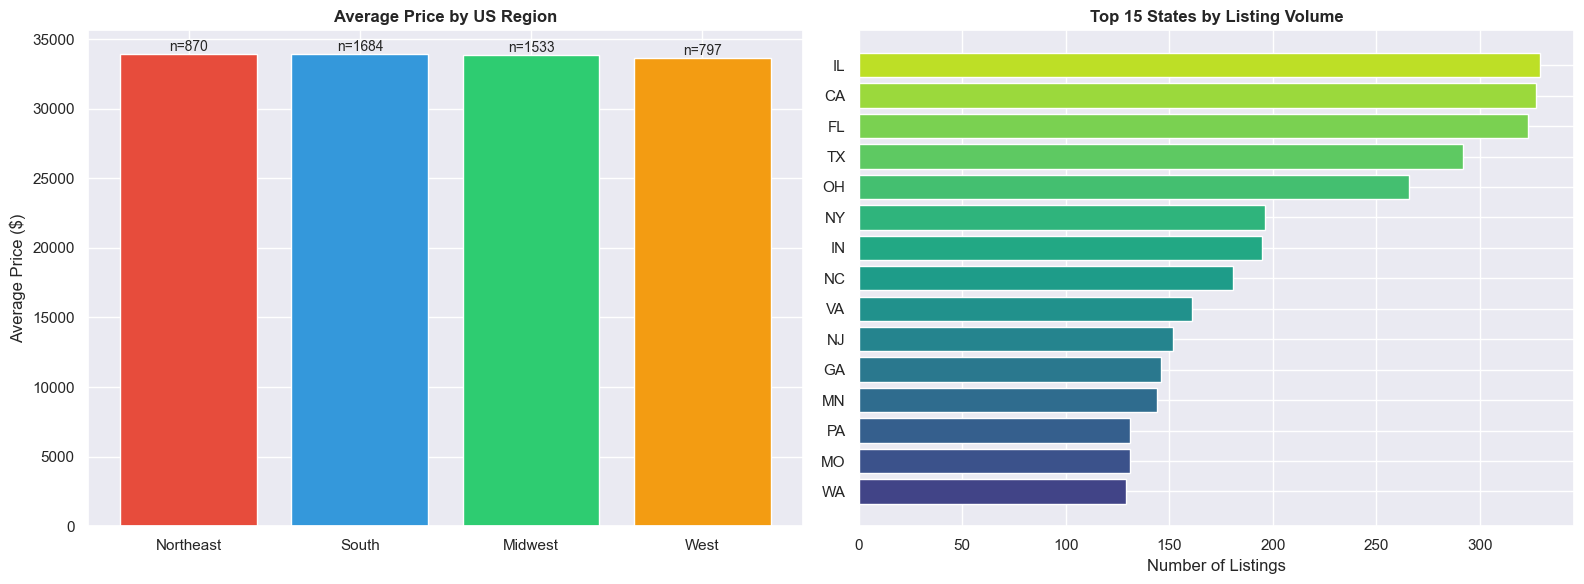

In [24]:
# Geographic analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Average Price by Region
region_stats = df.groupby('Region').agg(
    Avg_Price=('Price', 'mean'),
    Count=('Price', 'count'),
    Avg_Rating=('Consumer_Rating', 'mean')
).sort_values('Avg_Price', ascending=False)

colors_region = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
axes[0].bar(region_stats.index, region_stats['Avg_Price'], color=colors_region)
axes[0].set_title('Average Price by US Region', fontweight='bold')
axes[0].set_ylabel('Average Price ($)')
for i, (idx, row) in enumerate(region_stats.iterrows()):
    axes[0].text(i, row['Avg_Price'] + 200, f'n={int(row["Count"])}', 
                ha='center', fontsize=10)

# 2. Top 15 States by listing count
state_counts = df['State'].value_counts().head(15)
colors_state = plt.cm.viridis(np.linspace(0.2, 0.9, len(state_counts)))
axes[1].barh(state_counts.index[::-1], state_counts.values[::-1], color=colors_state)
axes[1].set_title('Top 15 States by Listing Volume', fontweight='bold')
axes[1].set_xlabel('Number of Listings')

plt.tight_layout()
plt.show()


In [25]:
# Model preference by Region
region_model = (df.groupby(['Region', 'Model_Family']).size()
                .reset_index(name='Count'))
region_top = (region_model.sort_values(['Region', 'Count'], ascending=[True, False])
              .groupby('Region').head(5))

fig = px.bar(region_top, x='Model_Family', y='Count', color='Region',
             barmode='group', title='Top 5 Model Families by Region',
             color_discrete_sequence=px.colors.qualitative.Set2)
fig.update_layout(xaxis_title='Model Family', yaxis_title='Number of Listings',
                  legend_title='Region', height=500)
fig.show()


## 6. Key Statistical Insights

Synthesizing the analysis into actionable business findings.

### 6.1 Best Value Models

Identifying models that deliver the highest consumer satisfaction relative to their price point — a powerful metric for both consumers and marketing teams.


 Best Value Models (New Cars) Highest Rating Per Dollar
              Avg_Value_Score  Avg_Price  Avg_Rating  Count
Model_Family                                               
HR-V                     1.68   28157.80        4.71    145
Civic                    1.52   30986.11        4.54     27
Accord                   1.44   31853.62        4.57    344
CR-V                     1.23   37268.86        4.54    548
Passport                 1.05   45343.44        4.77     97
Pilot                    1.04   43915.87        4.57    555
Ridgeline                1.03   45926.68        4.74    237
Odyssey                  1.01   45977.81        4.63    202


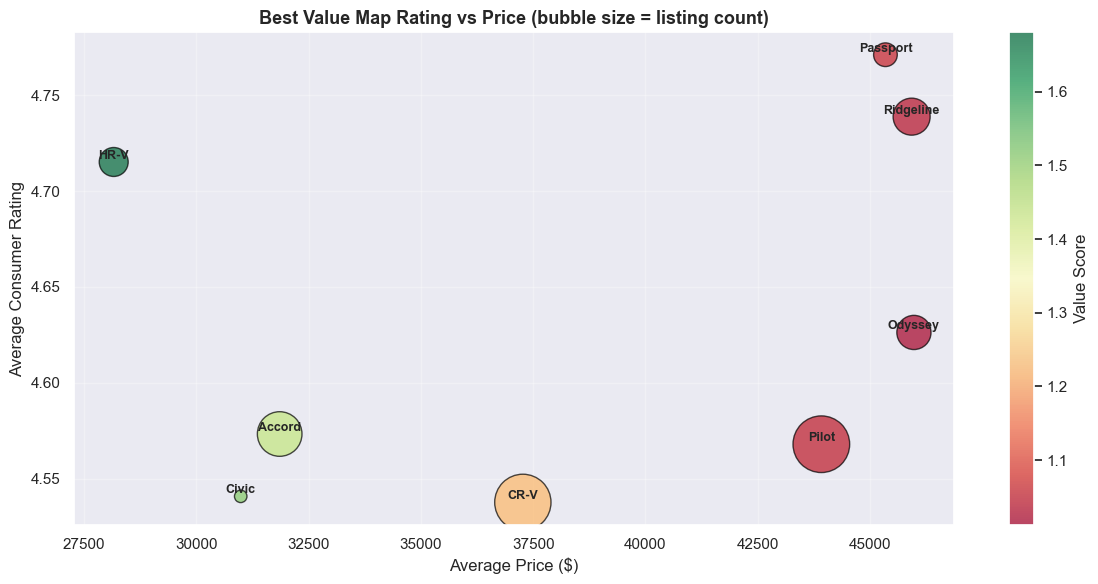

In [26]:
# Best Value Score: Consumer_Rating / (Price / 10000)
# Higher score = better value proposition
df_value = df[df['Has_Ratings'] & df['Condition'].isin(['New'])].copy()
df_value['Value_Score'] = df_value['Consumer_Rating'] / (df_value['Price'] / 10000)

# Top 10 Best Value Models (by average)
best_value = (df_value.groupby('Model_Family')
              .agg(
                  Avg_Value_Score=('Value_Score', 'mean'),
                  Avg_Price=('Price', 'mean'),
                  Avg_Rating=('Consumer_Rating', 'mean'),
                  Count=('Value_Score', 'count')
              )
              .sort_values('Avg_Value_Score', ascending=False))

# Only show models with enough data points
best_value = best_value[best_value['Count'] >= 10]

print(" Best Value Models (New Cars) Highest Rating Per Dollar")
print("=" * 70)
print(best_value.round(3).to_string())

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
scatter = ax.scatter(best_value['Avg_Price'], best_value['Avg_Rating'], 
                     s=best_value['Count'] * 3, alpha=0.7, 
                     c=best_value['Avg_Value_Score'], cmap='RdYlGn', edgecolors='black')
plt.colorbar(scatter, label='Value Score')

for model, row in best_value.iterrows():
    ax.annotate(model, (row['Avg_Price'], row['Avg_Rating']), 
                fontsize=9, ha='center', va='bottom',
                fontweight='bold')

ax.set_xlabel('Average Price ($)', fontsize=12)
ax.set_ylabel('Average Consumer Rating', fontsize=12)
ax.set_title('Best Value Map Rating vs Price (bubble size = listing count)', 
             fontweight='bold', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 6.2 Depreciation Leaders

Which Honda models lose the least value? Critical insight for resale value assessment.


Depreciation Ratio (Average Price Drop %)
  HR-V              17.2% ████████
  Civic             21.9% ██████████
  Passport          26.7% █████████████
  Accord            29.0% ██████████████
  Ridgeline         32.5% ████████████████
  CR-V              33.0% ████████████████
  Pilot             34.1% █████████████████
  Odyssey           36.8% ██████████████████


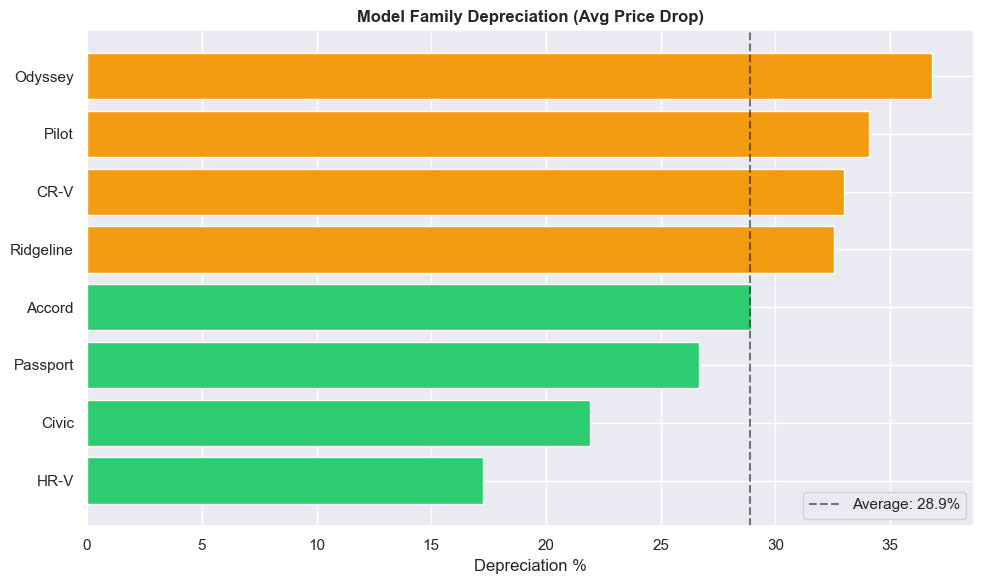

In [27]:
# Compare New vs Used average price by Model Family
new_prices = df[df['Condition'] == 'New'].groupby('Model_Family')['Price'].mean()
used_prices = df[df['Condition'] == 'Used'].groupby('Model_Family')['Price'].mean()

# Calculate depreciation ratio
depreciation_ratio = ((new_prices - used_prices) / new_prices * 100).dropna().sort_values()

# Filter to models that have both new and used listings (at least 10 each)
new_counts = df[df['Condition'] == 'New']['Model_Family'].value_counts()
used_counts = df[df['Condition'] == 'Used']['Model_Family'].value_counts()
valid_models = set(new_counts[new_counts >= 10].index) & set(used_counts[used_counts >= 10].index)
depreciation_ratio = depreciation_ratio[depreciation_ratio.index.isin(valid_models)]

print("Depreciation Ratio (Average Price Drop %)")
print("=" * 50)
for model, pct in depreciation_ratio.items():
    bar = "█" * int(abs(pct) / 2)
    print(f"  {model:<15} {pct:6.1f}% {bar}")

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ecc71' if x < 30 else '#f39c12' if x < 45 else '#e74c3c' for x in depreciation_ratio.values]
ax.barh(depreciation_ratio.index, depreciation_ratio.values, color=colors)
ax.set_xlabel('Depreciation %')
ax.set_title('Model Family Depreciation (Avg Price Drop)', fontweight='bold')
ax.axvline(x=depreciation_ratio.mean(), color='black', linestyle='--', alpha=0.5, 
           label=f'Average: {depreciation_ratio.mean():.1f}%')
ax.legend()
plt.tight_layout()
plt.show()


### 6.3 Consumer Satisfaction Leaders


In [28]:
# Overall satisfaction ranking by Model Family
df_rated = df[df['Has_Ratings']].copy()

satisfaction = (df_rated.groupby('Model_Family')
                .agg(
                    Avg_Overall_Rating=('Consumer_Rating', 'mean'),
                    Avg_Comfort=('Comfort_Rating', 'mean'),
                    Avg_Reliability=('Reliability_Rating', 'mean'),
                    Avg_Value=('Value_For_Money_Rating', 'mean'),
                    Total_Reviews=('Consumer_Review_#', 'sum'),
                    Count=('Consumer_Rating', 'count')
                )
                .sort_values('Avg_Overall_Rating', ascending=False))

satisfaction = satisfaction[satisfaction['Count'] >= 20]

print("⭐ Consumer Satisfaction Rankings (min. 20 reviews)")
print("=" * 80)
print(satisfaction.round(2).to_string())


⭐ Consumer Satisfaction Rankings (min. 20 reviews)
              Avg_Overall_Rating  Avg_Comfort  Avg_Reliability  Avg_Value  Total_Reviews  Count
Model_Family                                                                                   
Ridgeline                   4.69         4.95             4.93       4.32         502079    379
Insight                     4.65         4.64             4.87       4.77          85603     62
Passport                    4.62         4.91             4.88       4.75         511921    350
Odyssey                     4.60         4.86             4.79       4.24         562735    470
HR-V                        4.60         4.15             4.78       4.64         310812    228
Pilot                       4.59         4.92             4.87       4.83        1046702    886
Accord                      4.57         4.86             4.90       4.83         766807    685
Civic                       4.56         4.61             4.78       4.67         391

## 7. Export Clean Dataset

Save the cleaned and enriched dataset for use in the Streamlit dashboard.


In [29]:
# Select columns for export
export_cols = [
    # Original columns (cleaned)
    'Year', 'Make', 'Model', 'Condition', 'Price', 'Consumer_Rating',
    'Consumer_Review_#', 'Exterior_Color', 'Interior_Color', 'Drivetrain',
    'Fuel_Type', 'Transmission', 'Engine', 'VIN', 'Mileage',
    'Comfort_Rating', 'Interior_Design_Rating', 'Performance_Rating',
    'Value_For_Money_Rating', 'Exterior_Styling_Rating', 'Reliability_Rating',
    'State', 'Seller_Type',
    # Engineered features
    'Model_Family', 'Vehicle_Age', 'Is_Hybrid', 'Region',
    'MPG_City', 'MPG_Highway', 'MPG_Combined',
    'Engine_Displacement_L', 'Engine_Cylinders',
    'Price_Per_Mile', 'Has_Ratings'
]

df_export = df[export_cols].copy()

# Save to CSV
df_export.to_csv('honda_cleaned.csv', index=False)

print(f"✅ Cleaned dataset exported successfully!")
print(f"   File: honda_cleaned.csv")
print(f"   Shape: {df_export.shape[0]:,} rows × {df_export.shape[1]} columns")
print(f"   Size: {df_export.memory_usage(deep=True).sum() / 1024 / 1024:.1f} MB")


✅ Cleaned dataset exported successfully!
   File: honda_cleaned.csv
   Shape: 4,949 rows × 34 columns
   Size: 4.6 MB


## 8. Conclusion

### Key Findings:

1. **Pricing**: Honda vehicle prices range widely based on condition, model, and age. The median price for new vehicles is significantly higher, with trucks (Ridgeline) and SUVs (Pilot, Passport) commanding premium pricing.

2. **Depreciation**: Some model families retain value better than others. This insight is valuable for both consumers making purchase decisions and dealers setting trade-in prices.

3. **Consumer Satisfaction**: Honda vehicles consistently score high across all rating dimensions, with Reliability and Comfort being the strongest categories. The correlation between ratings reveals that satisfied customers tend to rate all dimensions highly.

4. **Hybrid Adoption**: Hybrid vehicles represent a growing segment of Honda's lineup. Despite higher average prices, hybrid models show competitive consumer ratings, particularly in the CR-V family.

5. **Geographic Trends**: Pricing and model preferences vary by US region, reflecting different consumer needs (e.g., AWD preference in northern states, fuel efficiency focus in western states).

### Next Steps:
- Interactive exploration via the **Streamlit Dashboard** (`app.py`)
- Deeper statistical modeling (regression, clustering) for predictive insights

---
*Analysis by: Ardi Gunawan Pratama | Dataset: Honda US Sales Data*
